### Large Language Models (LLMs): What They Are and Why They Matter

---

## What Is a Language Model?
- A **language model** assigns probabilities to **sequences of tokens**
- Core task: **predict the next token** given previous tokens  
- Formally:  
  > $( P(x_t \mid x_1, x_2, ..., x_{t-1}) $)

---

## What Makes a Model an **LLM**?

An **LLM (Large Language Model)** is a language model that is *large* along multiple dimensions:

### 1. Model Size
- Typically **≥ 1 billion parameters**
- Modern state-of-the-art models reach **hundreds of billions of parameters**

### 2. Training Data Scale
- Trained on **hundreds of billions to trillions of tokens**
- Largest models reach **tens of trillions of tokens**

### 3. Compute Requirements
- Require **massive GPU/TPU compute** during training
- Recent optimizations allow inference on **consumer-grade GPUs**

---

## Modern Definition of LLMs
- The term **LLM is relatively new**
- Earlier models (e.g., **BERT**) were sometimes grouped as LLMs
- **Current definition excludes encoder-only models**
  - Reason: encoder-only models **do not generate text**
- Today, LLMs are understood as:
  - **Text-in → text-out**
  - **Autoregressive**
  - **Decoder-only**

---

## Core Architecture of LLMs

### Decoder-Only Transformer
Modern LLMs keep only:
- **Masked Self-Attention**
- **Feedforward Neural Network (FFN)**
- **Residual Connections + Normalization**

They **remove the encoder entirely**

---

## Why Decoder-Only?
- Enables **autoregressive text generation**
- Scales better with data and compute
- Simpler training objective: **next-token prediction**
- Aligns naturally with chat, completion, and instruction-following tasks

---

## Examples of Decoder-Only LLMs
- GPT family
- LLaMA (Meta)
- Gemma (Google)
- Mistral
- Qwen
- DeepSeek

> **~90%+ of modern LLMs are decoder-only architectures**

---

## Key Takeaway
> **LLMs are large, decoder-only language models trained at massive scale to predict the next token—and this simplicity is the source of their power.**


### Mixture of Experts (MoE): Scaling LLMs Efficiently

---

## The Problem with Very Large Models
- Modern LLMs have **hundreds of billions of parameters**
- **Every parameter is activated** during:
  - Training
  - Inference
- This leads to:
  - High compute cost
  - High latency
  - High energy consumption

---

## Key Question
> **Do we really need to activate *all* parameters for every input?**

---

## Intuition: The Expert Analogy
Imagine a room with:
- A mathematician
- A physicist
- A chemist
- A historian

If you ask a **math question**, do you:
- Ask everyone? ❌  
- Ask only the mathematician? ✅

👉 **Current dense LLMs ask everyone**  
👉 **MoE asks only the relevant experts**

---

## Core Idea: Mixture of Experts (MoE)

### High-Level Concept
- Model is composed of **multiple experts**
- Each expert specializes in different patterns
- For a given input, **only a subset of experts is activated**

---

## Components of MoE

### 1. Experts
- Denoted as $( E_1, E_2, ..., E_n $)
- Each expert is typically a **neural network**
- Often implemented as **Feedforward Networks (FFNs)**

### 2. Gating Network (Router)
- Denoted as $( G(x) $)
- Decides **which experts to use**
- Outputs weights indicating expert importance

---

## MoE Output Formula

$$
\hat{y} = \sum_{i=1}^{n} G_i(x) \cdot E_i(x)
$$

Where:
- $( x $) = input
- $( E_i(x) $) = output of expert $( i $)
- $( G_i(x) $) = gate weight for expert $( i $)

---

## Training MoE Models
- **Experts and gate are trained jointly**
- Standard training loop:
  - Forward pass
  - Compute loss
  - Backpropagation
- Introduces **new challenges**, which will be discussed later

---

## Important Clarification
- The formula above **looks dense**
- In practice:
  - Only **top-k experts** are activated
  - Other experts receive **zero weight**
- This makes MoE **sparse in computation**, but **dense in capacity**

---

## Why MoE Matters
- **Massive parameter count** without massive compute cost
- Enables:
  - Better scaling
  - Lower inference cost
  - Higher specialization

---

## Key Takeaway
> **MoE allows LLMs to be large in capacity, but sparse in computation—activating only the experts that matter for each input.**


### Dense MoE vs Sparse MoE

---

## Two Types of Mixture of Experts (MoE)

---

## 1. Dense MoE

### Definition
- **All experts are involved** in computation
- Gate outputs **continuous weights** (between 0 and 1)
- Weights behave like a **probability distribution**

### Intuition
- Ask *everyone*, but **listen more to some**
- Example:
  - Math question → mathematician gets higher weight
  - Historian/chemist still contribute (small weight)

### Key Property
- ❌ **No compute savings**
- ❌ All experts activated
- ✅ More flexible combination of knowledge

---

## 2. Sparse MoE

### Definition
- **Only top-k experts are activated**
- All other experts receive **zero weight**
- $( k $) is a **hyperparameter** (commonly 1 or 2)

### Output Formula (Sparse)
$$
\hat{y} = \sum_{i \in \text{Top-k}} G_i(x)\cdot E_i(x)
$$

### Intuition
- Ask **only the most relevant experts**
- Everyone else stays inactive

### Key Property
- ✅ **Major compute savings**
- ✅ Scales model capacity without scaling compute
- ⚠️ Training becomes more complex

---

## Why Sparse MoE Is Preferred in Practice
- Activates **few experts per token**
- Enables:
  - Huge parameter counts
  - Lower inference cost
  - Faster generation

---

## FLOPS — Measure of Compute

### FLOPS = Floating-Point Operations
- Measures:
  - Number of additions
  - Number of multiplications
- Used to quantify **compute cost per forward pass**

### Dense vs Sparse (Compute View)
- **Dense MoE** → High FLOPS (all experts active)
- **Sparse MoE** → Low FLOPS (only top-k experts active)

---

## Key Takeaway
> **Sparse MoE keeps model capacity large while keeping computation (FLOPS) low by activating only the most relevant experts per input.**


### Mixture of Experts (MoE) Inside Decoder-Only LLMs

---

## Where Do Experts Live in an LLM?

LLMs are **decoder-only transformers**, made of repeated blocks containing:
- Masked self-attention
- Feedforward Neural Network (FFN)
- Add & Normalize

### Key Question  
If we introduce **Mixture of Experts (MoE)**, **where should it go?**

### Answer  
👉 **Inside the Feedforward Neural Network (FFN)**

---

## Why FFN Is the Right Place for MoE

### Parameter & Compute Perspective
- FFN projects:
  - From $( d_{\text{model}} \rightarrow d_{\text{ff}} \rightarrow d_{\text{model}} $)
- Typically:
  - $( d_{\text{ff}} \gg d_{\text{model}} $)
- FFN parameters scale as:
  $$
  \mathcal{O}(2 \cdot d_{\text{model}} \cdot d_{\text{ff}})
  $$

### Attention Layer Comparison
- Attention projections scale as:
  $$
  \mathcal{O}(d_{\text{model}} \cdot d_k)
  $$
- Much smaller than FFN

### Conclusion
> **FFN dominates parameter count and FLOPS → best target for MoE**

---

## What Are the “Experts” in MoE?

- **Each expert = one FFN**
- Instead of one FFN per layer:
  - We have **multiple FFNs (experts)**
- Only **top-k experts** are activated per token  
  (usually $( k = 1 $) or $( k = 2 $))

---

## Token-Level Routing

### Important Detail
- **Routing happens per token**
- Different tokens in the same sequence can go to:
  - Different experts
  - Different experts across layers

### Routing Flow (Per Layer)
1. Token passes through masked self-attention
2. Token representation becomes **contextual**
3. Router $( G $) receives token embedding
4. Router outputs probability over experts
5. Top-k experts are selected
6. Token is processed only by selected expert(s)

---

## Router (Gate) Network

- Router $( G $) is:
  - A trainable projection
  - Outputs a probability distribution over experts
- Applied **after attention, before FFN**
- **Layer-specific**:
  - Each transformer layer has its own router
  - Experts are **not shared across layers**

---

## Routing Collapse Problem

### What Is Routing Collapse?
- Router repeatedly selects:
  - Same expert(s)
- Other experts:
  - Never used
  - Never trained

### Why It’s Bad
- Wastes model capacity
- Reduces MoE effectiveness

---

## Load-Balancing Loss (Mitigation)

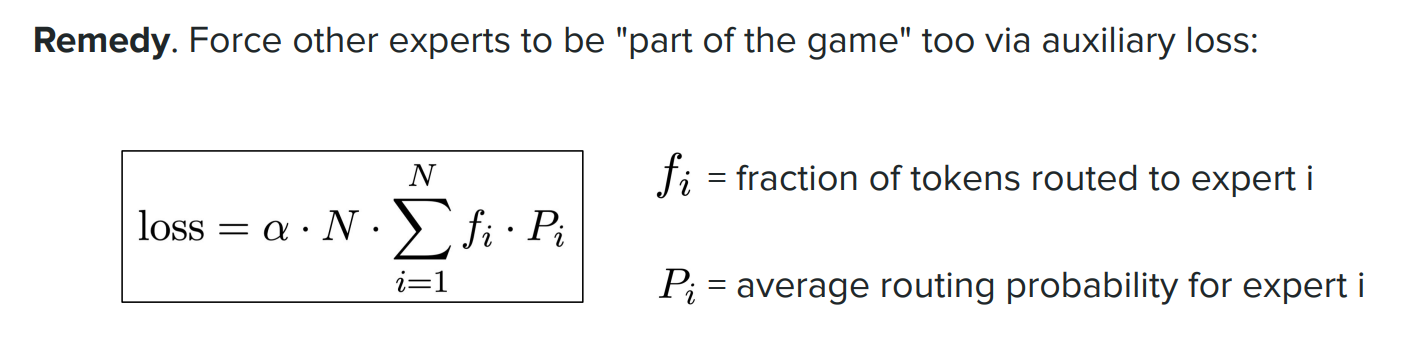


To prevent routing collapse, an **auxiliary loss** is added.

### Intuition
- Encourage **uniform expert usage**

### Key Quantities
- $( f_i $): fraction of tokens routed to expert $( i $)
- $( P_i $): average routing probability for expert $( i $)

### Effect
- Penalizes imbalance
- Encourages all experts to be used

> You don’t need to memorize the formula — just remember **it enforces balanced routing**

---

## Noisy Gating (Another Trick)

- Add noise to router logits
- Forces exploration
- Allows less-used experts to activate
- Similar spirit to **Dropout**

---

## Scaling with MoE

### Capacity vs Compute
- Increasing number of experts:
  - ✅ Increases total parameters
  - ❌ Does NOT increase active parameters per token

### Key Concept
- **Active parameters ≪ total parameters**

### Result
- Trillion-parameter models
- Inference cost similar to smaller dense models

---

## Expert Usage Visualization

- Tokens can be colored by:
  - Which expert processed them
- Desired behavior:
  - Diverse expert usage
  - Not all tokens routed to the same expert

---

## Key Takeaways

- MoE replaces FFN with **multiple FFNs**
- Routing is:
  - Token-level
  - Layer-specific
- Sparse MoE:
  - Scales capacity
  - Controls FLOPS
- Load balancing is critical to prevent routing collapse

---

**Next Topic → How LLMs Generate Text (Decoding & Sampling)**


### How LLMs Generate the Next Token (Decoding)

---

## Reminder: What an LLM Produces

- LLMs are **decoder-only language models**
- Given a sequence of tokens:
  $$
  x_1, x_2, \dots, x_t
  $$
- The model outputs a **probability distribution** over the vocabulary for:
  $$
  x_{t+1}
  $$

👉 This is **next-token prediction**

---

## Output of the Model

After the final linear layer + softmax, we get:

- A probability distribution over all tokens in the vocabulary
- Example:
  - $( P(\text{"A"}) = 0.40 $)
  - $( P(\text{"airplane"}) = 0.05 $)
  - $( P(\text{"fluffy"}) = 0.02 $)
  - …

So the question becomes:

> **How do we choose the next token from this distribution?**

---

## Decoding = Choosing the Next Token

The model does **not** directly output text  
It outputs **probabilities**

Decoding strategy = rule for selecting the next token from the distribution

---

## 1️⃣ Greedy Decoding

### Idea
- Always pick the token with the **highest probability**

$$
x_{t+1} = \arg\max P(x \mid x_1,\dots,x_t)
$$

### Pros
- Simple
- Fast
- Deterministic

### Cons
- Can be repetitive
- Often produces **boring / generic text**
- No diversity

---

## 2️⃣ Sampling (Random Sampling)

### Idea
- Sample the next token according to the probability distribution

### Pros
- More diverse outputs
- More human-like text

### Cons
- Can generate low-quality or incoherent tokens
- Sensitive to noise in low-probability tokens

---

## Why Decoding Matters

- Same model + same probabilities
- **Different decoding strategies → very different outputs**

Decoding is:
> A **design choice**, not learned by the model

---

## High-Level Takeaway

- LLMs output a **probability distribution**, not a single answer
- Text generation = repeatedly:
  1. Compute probabilities
  2. Choose next token using a decoding strategy
  3. Append token
  4. Repeat until EOS

---


## Decoding Strategies — Limitations of Greedy & Beam Search

---

## Greedy Decoding (Argmax)

**Rule**
$$
x_{t+1} = \arg\max P(x \mid x_1,\dots,x_t)
$$

**Problems**
- ❌ **No diversity**  
  - Deterministic → same input → same output every time
- ❌ **Locally optimal, not globally optimal**
  - Best next token ≠ best overall sequence

**Intuition**
- Choosing the highest-probability token now may block
  a higher-probability sequence later

---

## Why Greedy Can Fail (Key Insight)

- Sequence probability:
$$
P(x_1,\dots,x_T) = \prod_{t=1}^{T} P(x_t \mid x_{<t})
$$

- Greedy maximizes **each step**, not the **entire product**
- A lower-probability early token can lead to:
  - Higher probabilities later
  - Higher total sequence probability

---

## Beam Search

**Idea**
- Keep track of the top **k most probable sequences** at each step
- `k` = **beam size / beam width**

---

## Beam Search Algorithm (High-Level)

1. Start with **BOS**
2. Compute next-token probabilities
3. Keep top **k** candidate tokens
4. For each candidate:
   - Expand with next-token probabilities
5. Keep top **k sequences** (by score)
6. Repeat until EOS
7. Choose the best final sequence

---

## Scoring in Beam Search

- Use **log probabilities**:
$$
\log P(\text{sequence}) = \sum_t \log P(x_t \mid x_{<t})
$$

### Length Bias Problem
- Longer sequences → lower probability
- Beam search favors **short outputs**

### Fix
- **Length normalization**
$$
\frac{\log P(\text{sequence})}{(\text{length})^\alpha}
$$

---

## Limitations of Beam Search

- ❌ Computationally expensive
- ❌ Low diversity
- ❌ Produces “safe”, generic outputs
- ❌ Still optimizes likelihood, not creativity

---

## When Beam Search *Is* Used

✅ Machine Translation  
✅ Structured generation  
❌ Creative / conversational tasks (ChatGPT-style)

---

## Key Takeaway

- **Greedy decoding**: fast, deterministic, low quality
- **Beam search**: more globally optimal, but:
  - Expensive
  - Not diverse
- Modern chat models **do NOT use beam search**

---


## Sampling-Based Decoding in LLMs

---

## Why Sampling?

- Greedy decoding → deterministic, low diversity
- Beam search → expensive, still low creativity
- **Sampling** introduces randomness → more natural, diverse outputs  
  ✅ Used in modern chat models

---

## Basic Sampling

- Model outputs a **probability distribution** over next tokens
- Next token is **randomly sampled** according to these probabilities
- High-probability tokens are more likely, low-probability tokens still possible

⚠️ Issue:  
- Very low-probability (nonsensical) tokens can still be sampled

---

## Top-k Sampling

**Idea**
- Keep only the **top k most probable tokens**
- Renormalize probabilities
- Sample from this reduced set

**Effect**
- Prevents extremely unlikely tokens
- Still allows randomness

---

## Top-p (Nucleus) Sampling

**Idea**
- Choose the **smallest set of tokens** whose cumulative probability ≥ `p`
- Sample from this dynamic set

**Comparison**
- Top-k → fixed number of tokens
- Top-p → adaptive number of tokens

---

## Where Probabilities Come From

1. Decoder produces final hidden state
2. Linear projection:
$$
\mathbb{R}^{d_{\text{model}}} \rightarrow \mathbb{R}^{|V|}
$$
3. Apply **Softmax** → probability distribution over vocabulary

---

## Softmax with Temperature

$$
P(x_i) = \frac{e^{z_i / T}}{\sum_j e^{z_j / T}}
$$

Where:
- $( z_i $) = logit for token $( i $)
- $( T $) = **temperature**

---

## Effect of Temperature

### Low Temperature (T < 1)
- Sharper distribution
- High-probability tokens dominate
- More **deterministic**, less creative

### High Temperature (T > 1)
- Flatter distribution
- More randomness
- More **diverse**, creative, but riskier

---

## Practical Intuition

- **Low T** → factual, precise answers
- **High T** → creative, exploratory answers
- Default chat models use:
  - Sampling + Top-p
  - Moderate temperature

---

## Key Takeaways

- Sampling is used **at inference time**
- Common setup in practice:
  - Temperature + Top-p sampling
- Decoding strategy strongly affects:
  - Diversity
  - Creativity
  - Reliability of outputs


### Temperature, Decoding, Prompting & In-Context Learning

---

## Temperature in Softmax (Formal Intuition)

Softmax with temperature:
$$
P(x_i) = \frac{e^{x_i / T}}{\sum_j e^{x_j / T}}
$$

### Low Temperature ( $( T \to 0 $) )
- Distribution becomes **spiky**
- Probability mass concentrates on the **highest logit**
- Behavior → **Greedy / deterministic**
- Output quality: precise, factual, repetitive

### High Temperature ( $( T \to \infty $) )
- Distribution becomes **flat**
- Probabilities approach **uniform**
- Behavior → **high randomness**
- Output quality: creative, diverse, riskier

### Key Insight
- Transformer is **fully deterministic**
- **Only randomness comes from token sampling**
- Temperature controls **how sharp or flat** sampling is

---

## Determinism in Practice
- Theoretically:  
  - $( T = 0 $) → deterministic output
- Practically:
  - GPU floating-point order, parallelism → **minor non-determinism**
- True determinism is **hard in real hardware**

---

## Guided Decoding (Structured Outputs)

### Problem
- Asking: *“Generate valid JSON”*  
- Model may still output **invalid JSON**

### Naive Fix
- Retry generation until valid output appears

### Guided Decoding
- Restrict **allowed next tokens** at each step
- Invalid tokens are **masked out**
- Often implemented using:
  - Finite State Machines (FSM)
  - Context-Free Grammars (CFG)

---

## Context Length (a.k.a. Window Size)

Equivalent terms:
- Context length
- Context size
- Window size

### Typical Sizes
- Tens of thousands → hundreds of thousands
- Some models → **millions of tokens**

### Important Caveat: Context Rot
- More context ≠ better performance
- Retrieval accuracy **decreases** with long noisy contexts
- “Needle in a Haystack” experiments confirm this

### Practical Lesson
> **Relevant context > large context**

---

## Prompt Structure (Mental Model)

A prompt can be decomposed into:

1. **Context**
   - System setup, background, role
2. **Instructions**
   - What task to perform
3. **Input**
   - Data the task operates on
4. **Constraints**
   - Output format, safety rules, style

---

## In-Context Learning (ICL)

Learning **without changing model weights**

---

### Zero-Shot Learning
- Only instructions + input
- No examples provided
- Relies purely on model’s pretraining

---

### Few-Shot Learning
- Provide input–output examples
- Model imitates demonstrated behavior
- Pros:
  - Better task alignment
- Cons:
  - Higher token cost
  - Risk of over-constraining model

---

### Modern Observation
- Strong models + **good instructions**
- Can outperform few-shot prompting
- Reason: better generalization via reasoning

---

## Chain-of-Thought (CoT)

### Idea
- Ask the model to **explain reasoning**
- Improves performance on:
  - Math
  - Logic
  - Multi-step problems

### Benefits
- Higher accuracy
- Debuggable outputs
- Transparent failure modes

### Trade-off
- More tokens
- Higher inference cost

---

## Self-Consistency

### Technique
1. Sample multiple responses
2. Extract final answers
3. Majority voting

### Why It Works
- Reasoning paths vary
- Correct answer appears **more often**

### Parallelism
- All samples generated **independently**
- Latency ≈ max(single sample time)

---

## Key Takeaways

- **Temperature** controls creativity vs determinism
- **Sampling + Top-k / Top-p** is standard for LLMs
- Larger context ≠ better reasoning
- Prompt quality often beats examples
- CoT + self-consistency boosts reliability
- Decoding strategy is as important as the model itself


### Efficient Inference in Large Language Models (LLMs)

---

## Why Inference Efficiency Matters
- LLMs have **billions to trillions of parameters**
- Generation requires:
  - Many **forward passes**
  - Heavy **memory + compute**
- Goal: **generate tokens faster and cheaper**  
  → without changing model behavior (exact)  
  → or with acceptable approximations

---

## Two Broad Categories of Inference Optimizations

### 1️⃣ Exact Techniques
> Same outputs, fewer computations

- Avoid redundant computations
- Better memory reuse
- Algebraic reformulations

### 2️⃣ Approximate Techniques
> Slight approximation, much cheaper inference

- Architectural simplifications
- Embedding-level tricks
- Token-generation shortcuts

---

## Focus Area 1: Attention-Level Optimizations

---

## Key Observation (Decoder-Only Models)

At step *t*:
- Query **Qₜ** → new (must be computed)
- Keys **K₁…Kₜ₋₁** → already computed
- Values **V₁…Vₜ₋₁** → already computed

➡️ **Redundant recomputation exists**

---

## KV Cache (Key–Value Cache)

### Idea
- **Cache K and V** from previous tokens
- Reuse them during next-token generation

### What Gets Cached
- Keys (K)
- Values (V)
- Per layer, per head (or per group in GQA)

### What Is NOT Cached
- Queries (Q)  
  → Only needed for current token

### Benefit
- Avoid recomputing K, V for past tokens
- Massive speed-up during autoregressive decoding

---

## KV Cache vs Training

- **Training**:
  - Teacher forcing
  - Full sequence processed at once
  - KV cache not needed

- **Inference**:
  - Token-by-token generation
  - KV cache is critical

---

## Memory Trade-off
- KV cache grows **linearly with sequence length**
- Becomes dominant memory cost for long contexts

---

## Reducing KV Cache Size

### Recall from Previous Lecture 👇

### Grouped Query Attention (GQA)

- Share **K and V** projections across groups of heads
- Queries remain per-head

| Variant | Keys/Values |
|------|------------|
| MHA | One per head |
| GQA | Shared per group |
| MQA | Fully shared |

### Why This Helps
- KV cache size ∝ number of K/V heads
- GQA drastically reduces memory footprint
- Widely used in modern LLMs

---

## Combined Effect

**KV Cache + GQA**
- Faster decoding
- Lower memory usage
- No loss in exactness

---

## Key Takeaways

- Autoregressive decoding repeats work → **cache it**
- KV cache is the single most important inference optimization
- GQA further reduces cache size
- These techniques are **exact** (no approximation)
- Foundation for fast LLM serving in production

---



### Efficient Inference in Large Language Models (LLMs)

---

## Hardware-Aware KV Cache Management

### Problem: Naive KV Cache Allocation
- At inference time, max context length is unknown (stop at EOS)
- Naive approach:
  - Reserve full `max_context_length` KV cache **per request**
- In multi-user inference servers:
  - Huge **memory waste**
  - Limits number of concurrent requests

---

## Memory Fragmentation Issues

### 1. Internal Fragmentation
- Reserved KV cache space > actually used tokens
- Unused but blocked memory

### 2. External Fragmentation
- GPU memory allocator creates gaps
- Blocks are not always contiguous

---

## PagedAttention (vLLM)

### Core Idea
- Allocate KV cache in **fixed-size blocks** (pages)
- Example: block size = 16 tokens
- Allocate blocks **only when needed**

### Benefits
- Avoids reserving full context upfront
- Dramatically reduces:
  - Internal fragmentation
  - External fragmentation

### Key Mechanism
- Logical token positions → mapped to physical KV cache blocks
- Indirection layer manages mapping

---

## KV Cache Compression

### Observation
- KV cache dominates memory usage
- Keys and values:
  - High dimensional
  - Stored per head, per layer, per token

---

## Multi-Latent Attention (DeepSeek)

### Vanilla Multi-Head Attention
- For each token:
  - `h` key vectors
  - `h` value vectors
- Stored separately → large memory footprint

---

### Multi-Latent Attention: Key Ideas

#### 1. Low-Rank Factorization
- Project token → **lower-dimensional latent space**
- Then project latent → key/value space
- Reduces KV dimensionality

#### 2. Shared Compression
- Same compressed latent used for:
  - Keys
  - Values

#### 3. Shared Across Heads
- One latent representation shared across all heads
- Instead of `h` KV vectors → **1 per token per layer**

---

### Benefits
- Massive KV cache reduction
- Lower memory bandwidth usage
- Empirically improves performance (regularization effect)

---

## Token-Level Inference Optimizations

---

## Speculative Decoding

### Motivation
- Big LLM = slow per token
- Small model = fast but less accurate

---

### Architecture
- **Draft model** (small, fast)
- **Target model** (large, accurate)

---

### Algorithm (High-Level)

1. Draft model generates multiple future tokens
2. Target model:
   - Computes probabilities for all draft tokens **in one forward pass**
3. Acceptance–rejection rule:
   - Accept token if target probability ≥ draft probability
   - Otherwise reject and resample
4. If all accepted → advance multiple tokens at once
5. If rejected → resume from last accepted token

---

### Why It Works
- Acceptance–rejection guarantees:
  - Final distribution matches **target model**
- Proven via law of total probability

---

### Why It’s Fast
- Big model forward pass is **memory-bound**
- One pass ≈ many passes cost-wise
- Small model handles most token generation

---

## Multi-Token Prediction (MTP)

### Difference from Speculative Decoding
- Draft and target models are **inside the same network**

---

### Key Ideas
- Multiple output heads predict:
  - Next token
  - Token +1
  - Token +2
  - …
- Training objective:
  - Predict multiple future tokens jointly

---

### Inference
- First head = target model
- Other heads = draft predictions
- Greedy acceptance (simplified vs speculative decoding)

---

### Trade-offs
- No exact distribution-matching guarantee
- Faster inference
- Simpler deployment (single model)

---

## Summary: Inference Optimization Toolbox

### Exact Methods
- KV cache
- GQA / MQA
- PagedAttention
- KV compression (Multi-Latent Attention)

### Approximate / Hybrid Methods
- Speculative decoding
- Multi-token prediction

---

## Key Takeaway
Modern LLM inference is **memory-bound**, not compute-bound.  
Most optimizations focus on:
- Reusing computations
- Reducing KV cache size
- Generating multiple tokens per forward pass

---
